# Activity: Evaluate simple linear regression

## Introduction

For this activity, you are part of an analytics team that provides insights about marketing and sales. You have been assigned to a project that focuses on the use of influencer marketing, and you would like to explore the relationship between marketing promotional budgets and sales. The dataset provided includes information about marketing campaigns across TV, radio, and social media, as well as how much revenue in sales was generated from these campaigns.


Based on this information, leaders in your company will make decisions about where to focus future marketing efforts, so it is critical to have a clear understanding of the relationship between the different types of marketing and the revenue they generate.

This activity will develop your knowledge of linear regression and your skills evaluating regression results which will help prepare you for modeling to provide business recommendations in the future.

### Import packages

Import relevant Python libraries and packages. In this activity, you will need to use `pandas`, `pyplot` from `matplotlib`, and `seaborn`.

In [8]:
# Import pandas, pyplot from matplotlib, and seaborn.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


### Import the statsmodel module and the ols function

Import the `statsmodels.api` Python module using its common abbreviation, `sm`, along with the `ols()` function from `statsmodels.formula.api`. To complete this, you will need to write the imports as well.

In [11]:
# Import the statsmodel module.
import statsmodels.api as sm


# Import the ols function from statsmodels.
from statsmodels.formula.api import ols



### Load the dataset

`Pandas` was used to load the provided dataset `marketing_and_sales_data_evaluate_lr.csv` as `data`,


In [14]:
# RUN THIS CELL TO IMPORT YOUR DATA.

## url = "https://github.com/dyyland23-glitch/Marketing_Evaluate_simple_linear_regression/blob/main/marketing_and_sales_data_evaluate_lr.csv"



# RUN THIS CELL TO IMPORT YOUR DATA.
url = "https://raw.githubusercontent.com/dyyland23-glitch/Marketing_Evaluate_simple_linear_regression/main/marketing_and_sales_data_evaluate_lr.csv"

data = pd.read_csv(url)




In [16]:
# Display the first five rows.
data.head(10)




,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
5,29.0,9.614382,1.027163,105.889148
6,55.0,24.893811,4.273602,198.679825
7,31.0,17.355042,2.289855,108.733932
8,76.0,24.648898,7.130116,270.189400
9,13.0,0.431128,2.229423,48.280582


## Step 2: Data exploration



Start EDA  to familiarize yourself with the data and prepare it for modeling.

The features are:
* TV promotion budget (in millions of dollars)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)

-----------

Each row corresponds to an independent campaign in `TV`, `Social_Media`, and `Radio`  to increase `Sales`.



The business would like to determine which feature most strongly predicts `Sales` so they have a better understanding of what promotions they should invest in.


**What are some reasons for conducting an EDA before constructing a simple linear regression model?**


To familiarize oneself with the data, the stats in our data, the size of the data (Columns and rows),
to check the consistency of the data, to check wether there are any missing values or NaNs, and start to get an idea of what model would best fit the dataset. use describe()  attribute,  isna() attribute

### Explore the data size

Calculate the number of rows and columns in the data.

In [20]:
# Display the shape of the data as a tuple (rows, columns).

data.shape

(4572, 4)

### Explore the independent variables

There are three continuous independent variables: `TV`, `Radio`, and `Social_Media`. To understand how heavily the business invests in each promotion type, use `describe()` to generate descriptive statistics for these three variables.

In [21]:
# Generate descriptive statistics about TV, Radio, and Social_Media.

data.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [22]:
data.isna()

,TV,Radio,Social_Media,Sales
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
4567,False,False,False,False
4568,False,False,False,False
4569,False,False,False,False
4570,False,False,False,False


In [23]:
# We are writing this code to figure out how many cells are missing or NaNs

data.isna().any(axis=1).sum()



np.int64(26)

In [24]:
# From the row above, We know there are 26 cells that are missing or NaNs

data[data.isna().any(axis=1)]

,TV,Radio,Social_Media,Sales
13,NaN,22.351667,3.031815,276.165351
26,NaN,34.111674,4.624148,342.913372
46,NaN,34.859637,7.781417,318.969784
75,NaN,6.482293,0.866845,91.177216
99,NaN,7.635819,1.554146,56.186730
119,NaN,30.470485,6.806919,336.818690
141,NaN,9.164464,1.096681,65.259189
163,NaN,38.118424,6.676611,328.555184
182,81.0,26.425422,NaN,288.649441
183,NaN,1.287060,0.396179,56.545293


In [26]:
# We are gonna do cleaning and rmove all the NaNs cells

data.dropna(axis=0)



,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411


In [27]:
## we are gonna re--assign the "data" variable with the cleaned data

data = data.dropna(axis=0)


### Explore the dependent variable



Display the percentage of missing values in the `Sales` column

In [41]:
# Calculate the average missing rate in the sales column.
### I know that everytime a prompt invloves the Average I use  the mean() function.
### I will create a new variable called Missing_values

Missing_values = data["Sales"].isna().mean()




#### data[data.isna().Sales(axis=0)]  ==  'Series' object is not callable


This above was the wrong code because

you needed to break down the code in x2 to find # Calculate the average missing rate in the sales column.


1. First you need to the missing_values in the sales column
2. Then you need to create a new variable called missing_values and  round long decimals to x2 decimals using the round()








In [42]:
# Display the percentage of missing values in the `Sales` column in the DataFrame `data`.
# Convert the missing_sales from a decimal to a percentage and round to 2 decimal place.



### the round() function reduces off decimals to two decimal places:
Missing_sales = round(missing_sales * 100, 2)

### This is how the function works   round(number, number_of_deimal_digits)



# Display the results (missing_sales must be converted to a string to be concatenated in the print statement).
print('Percentage of promotions missing Sales: ' + str(missing_sales) + '%')



Percentage of promotions missing Sales: 0.0%


**Question:** What do you observe about the percentage of missing values in the `Sales` column?


there is 0% of missing values in the Sales column since I remooved everything
with the data.dropa() earlier

## Create a histogram to visualize the distribution of `Sales`.

Text(0, 0.5, 'Number of campaigns')

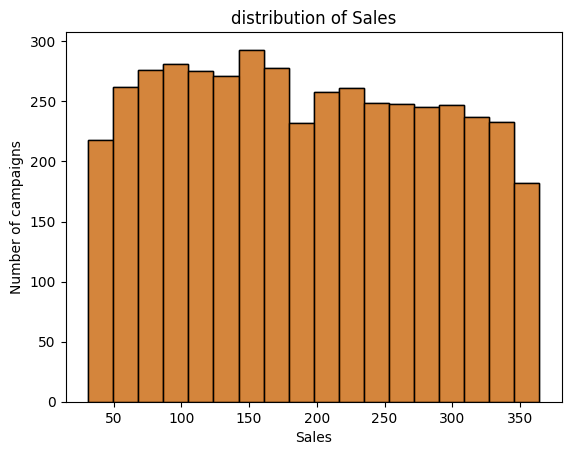

In [55]:
# Create a histogram of the Sales.


from seaborn import histplot

histplot(data["Sales"])


# Add a title
fig=sns.histplot(data["Sales"])

fig.set_title("distribution of Sales")
fig.set_ylabel("Number of campaigns")


**Question:** What do you observe about the distribution of `Sales` from the preceding histogram?


the histplot above takes into account all x3 marketing channels campaigns
and gives you how many sales (in MIllion dollars)
#### Overall it is too general to be insightful

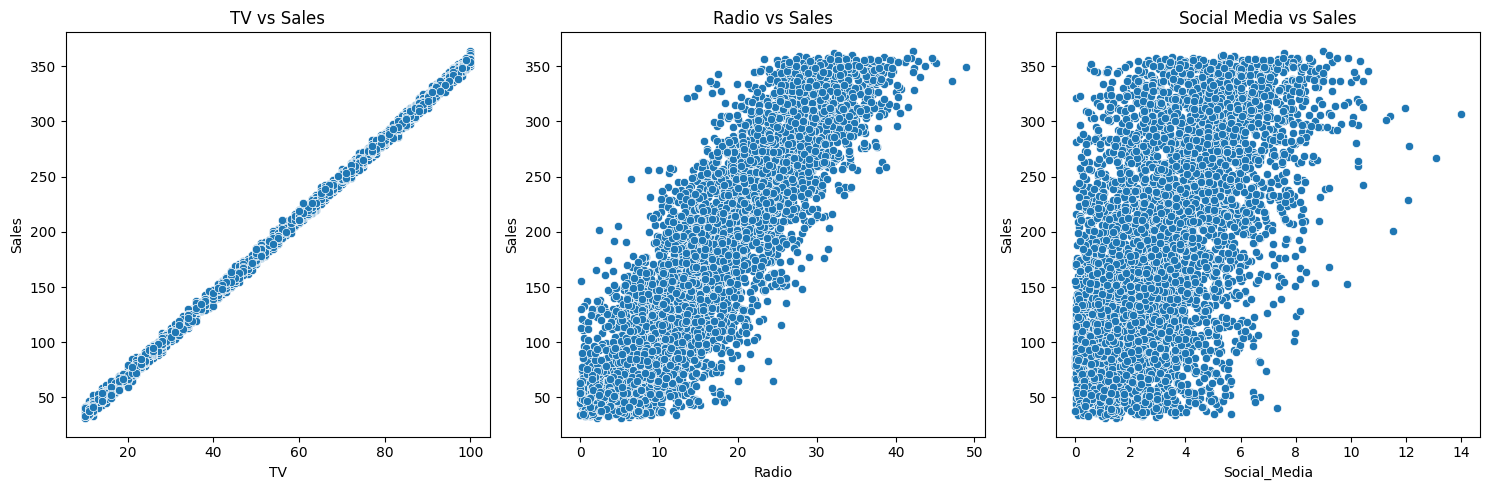

In [59]:
## The chart aboves gives you how many sales per each marketing channel campaign

import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for each channel
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(x='TV', y='Sales', data=data, ax=axes[0])
axes[0].set_title('TV vs Sales')

sns.scatterplot(x='Radio', y='Sales', data=data, ax=axes[1])
axes[1].set_title('Radio vs Sales')

sns.scatterplot(x='Social_Media', y='Sales', data=data, ax=axes[2])
axes[2].set_title('Social Media vs Sales')

plt.tight_layout()
plt.show()

the charts above are very insightful,
from looking at them we can see that Social_Media Marketing
has the best ROIs roughly for every 8 mimllion dollars in ads
we get anywhere from 100 millions to 350 millions

## Step 3: Model building

Create a pairplot to visualize the relationships between pairs of variables in the data.



**You will use this to visually determine which variable has the strongest linear relationship with `Sales`**



 This will help you select the X variable for the simple linear regression.

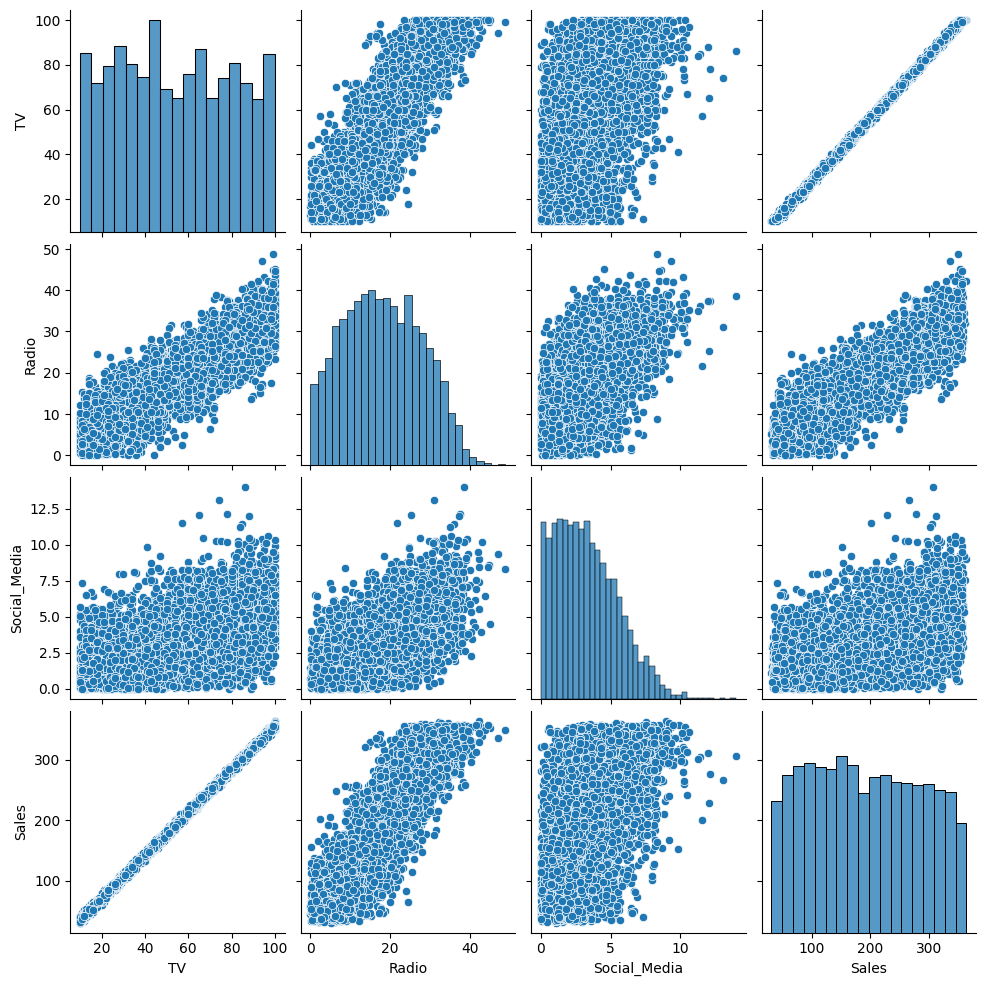

In [61]:
# Create a pairplot of the data.
sns.pairplot(data)

**Question:** Which variable did you select for X? Why?

TV campaigns and sales how the strongest linear correlation



### Build and fit the model with the varaibles of interest

In [73]:
# Im creating a subset of my data.

ols_data = data[["TV","Sales"]]


In [74]:
ols_data.head(10)

,TV,Sales
0,16.0,54.732757
1,13.0,46.677897
2,41.0,150.177829
3,83.0,298.246340
4,15.0,56.594181
5,29.0,105.889148
6,55.0,198.679825
7,31.0,108.733932
8,76.0,270.189400
9,13.0,48.280582


Write the linear regression formula

Model the relationship between the two variables of interest. (TV campaigns And Sales )

### Write the linear regression formula.
### Save it in a variable.

ols_formula = "Sales ~ Radio"


...








In [75]:
# Define the OLS formula  ==  the linear regression formula.

ols_formula = "Sales ~ TV"



Ellipsis

Replace the comment with the correct code. Use the variable you chose for `X` for building the model.

In [76]:
from statsmodels.formula.api import ols


# implement OLS
OLS = ols(formula = ols_formula, data = ols_data)


# Fit the model and save the results inside model variable.
model = OLS.fit()



In [79]:
# Display the model results.

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:43:53   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

To justify using simple linear regression, check that the four linear regression assumptions are not violated.

* Linearity
* Independent Observations
* Normality
* Homoscedasticity

### Model assumption: Linearity

The linearity assumption requires a linear relationship between the independent and dependent variables. Check this assumption by creating a scatterplot comparing the independent variable with the dependent variable.

Create a scatterplot comparing the X variable you selected with the dependent variable.

<Axes: xlabel='TV', ylabel='Sales'>

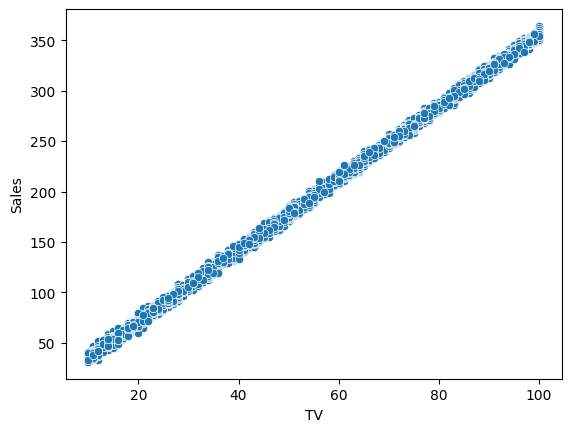

In [83]:
# Create a scatterplot comparing X and Sales (Y).

sns.scatterplot(x="TV", y="Sales", data = ols_data)

**QUESTION:** Is the linearity assumption met?


The linearity assumption is met for every time the x variables increases (TV),
so will the y variable.

### Model assumption: Independence

As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

### Model assumption: Normality

The normality assumption states that the errors are normally distributed.

Create two plots to check this assumption:

* **Plot 1**: Histogram of the residuals
* **Plot 2**: Q-Q plot of the residuals


...

In [92]:
# Calculate the residuals.

residuals = model.resid



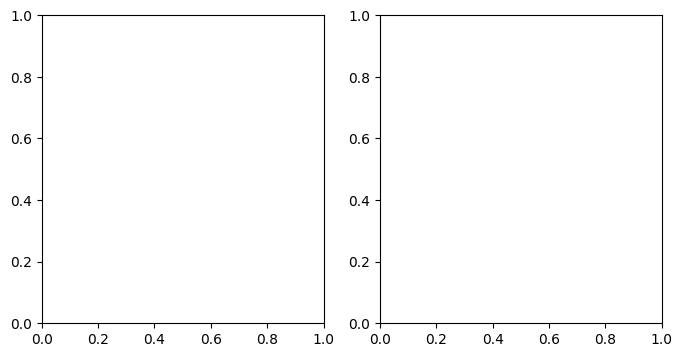

In [101]:
# Create a 1x2 plot figures.

fig, axes = plt.subplots(1, 2, figsize=(8, 4))



Text(0.5, 1.0, 'Histogram of residuals')

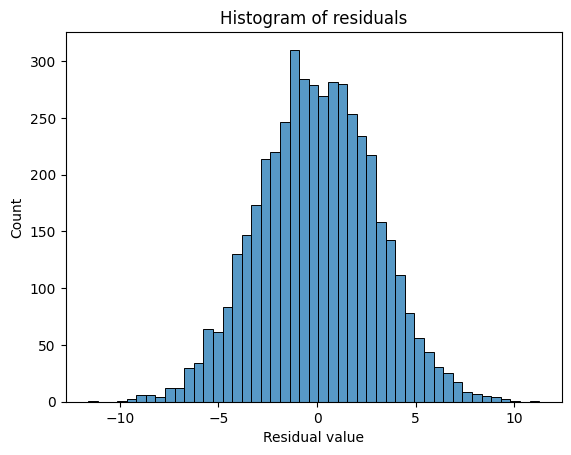

In [100]:
# Create a histogram with the residuals.

fig = sns.histplot(residuals)
fig.set_xlabel("Residual value")
fig.set_title("Histogram of residuals")



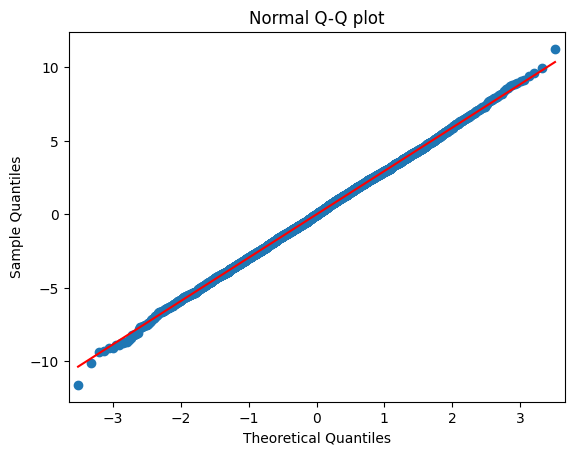

In [99]:
# Create a Q-Q plot of the residuals.
# Set the title of the Q-Q plot.
# Show the plot.

sm.qqplot(residuals, line="s")
plt.title("Normal Q-Q plot")
plt.show()


**Question:** Is the normality assumption met?

yes the qqplot line overlaps the TV-Sales correlation, with the expected variance at the tails (ends) of the graph

### Model assumption: Homoscedasticity

 Homoscedasticity just means the errors (residuals) stay evenly spread out the whole way through. Whether your TV spend is low, medium, or high, the model's misses don't get wilder or blow up at one end—the variance stays consistent across all fitted values.



----


 Add a line at $y = 0$
 To visualize the variance of residuals above and below $y = 0$.

In [111]:
# Get fitted values.

X = ols_data["TV"]


# we are gonna create a variable to store these predictions called Fitted_values
fitted_values = model.predict(X)



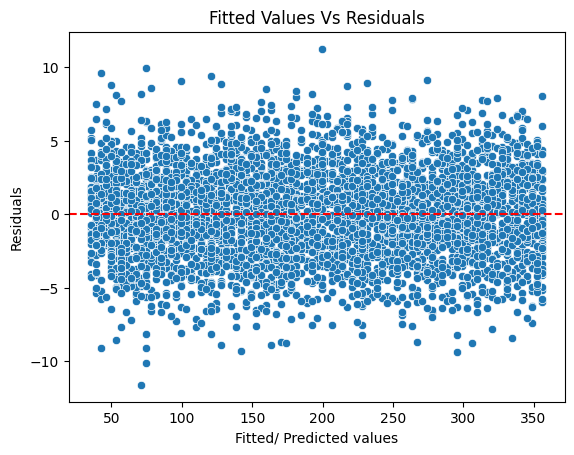

In [118]:
# Create a scatterplot with the fitted values from the model and the residuals.

fig = sns.scatterplot (x=fitted_values, y=residuals)
fig.set_xlabel("Fitted/ Predicted values")
fig.set_ylabel("Residuals")
fig.set_title("Fitted Values Vs Residuals")


# Add a line at  y=0  To visualize the variance of residuals above and below y=0.

fig.axhline(0, color="red", linestyle="--")


plt.show()





**QUESTION:** Is the homoscedasticity assumption met?


Homoscedasticity : Yes, met. Looking at the scatterplot of residuals against fitted values, the points form a random cloud/band around zero. The vertical spread (dispersion) of the points remains fairly uniform and consistent across all fitted values, with no obvious funnel, cone, or fan shape.



### Display the OLS regression results

If the linearity assumptions are met, you can interpret the model results accurately.

Display the OLS regression results from the fitted model object, which includes information about the dataset, model fit, and coefficients.

In [121]:
# Display the model_results defined previously.

model.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:46:49   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** The R-squared on the preceding output measures the proportion of variation in the dependent variable (Y) explained by the independent variable



 (X). What is your intepretation of the model's R-squared?
 it tells how statistically reliable is the OLS model


### Interpret the model results

With the model fit evaluated, assess the coefficient estimates and the uncertainty of these estimates.

**Question:** Based on the preceding model results, what do you observe about the coefficients?


at x=o the intercecpt (sales values) will be -o.1325


for every 1 million increase in TV ad spent (x variiable), the y variable will
increase in  (sales) will increase 3.56 Millions $$

**Question:** How would you write the relationship between X and `Sales` in the form of a linear equation?

 y = slope * x + y-intercept

 y = m*x + b


sales = 3.56 * x(TV) -0.1325




**Question:** Why is it important to interpret the beta coefficients?

### Measure the uncertainty of the coefficient estimates

Model coefficients are estimated. This means there is an amount of uncertainty in the estimate. A p-value and $95\%$ confidence interval are provided with each coefficient to quantify the uncertainty for that coefficient estimate.

Display the model results again.

In [116]:


# Display the model_results defined previously.



### YOUR CODE HERE ###

**Question:** Based on this model, what is your interpretation of the p-value and confidence interval for the coefficient estimate of X?

**Question:** Based on this model, what are you interested in exploring?

**Question:** What recommendations would you make to the leadership at your organization?

## Considerations

**What are some key takeaways that you learned from this lab?**

**What findings would you share with others?**

**How would you frame your findings to stakeholders?**


#### **References**

Saragih, H.S. (2020). [*Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).

Dale, D.,Droettboom, M., Firing, E., Hunter, J. (n.d.). [*Matplotlib.Pyplot.Axline — Matplotlib 3.5.0 Documentation*](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.axline.html).

**Congratulations!** You've completed this lab.